In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
import os

print(os.getcwd())

C:\Users\PRITWISH\OneDrive\AtmoSync\notebooks


In [4]:
df = pd.read_csv("../data/processed/iot_telemetry_features.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1785, 35)


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,max_vibration,warning_count,anomaly_count,avg_environmental_risk,commodity_avg_temperature,commodity_avg_humidity,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk
0,CONT_001,2026-09-10 17:39:32.831215,Avocado,3.94,71.79,0.29,WARNING,2026-09-10,17,3,...,0.59,62,36,2.894118,9.129163,88.956719,0.194729,71,53,2.952489
1,CONT_004,2026-09-10 17:39:34.852445,Mango,11.72,88.98,0.12,NORMAL,2026-09-10,17,3,...,0.59,81,36,2.942149,11.575468,86.437340,0.193234,97,51,2.689362
2,CONT_005,2026-09-10 17:39:36.870612,Tomato,10.18,91.05,0.15,NORMAL,2026-09-10,17,3,...,0.59,62,40,2.818182,10.869107,87.423878,0.184183,88,39,2.821351
3,CONT_005,2026-09-10 17:39:38.890192,Avocado,6.54,85.30,0.17,NORMAL,2026-09-10,17,3,...,0.59,62,40,2.818182,9.129163,88.956719,0.194729,71,53,2.952489
4,CONT_005,2026-09-10 17:39:40.899424,Tomato,14.06,100.00,0.33,WARNING,2026-09-10,17,3,...,0.59,62,40,2.818182,10.869107,87.423878,0.184183,88,39,2.821351


In [5]:
df["condition"].value_counts()

condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64

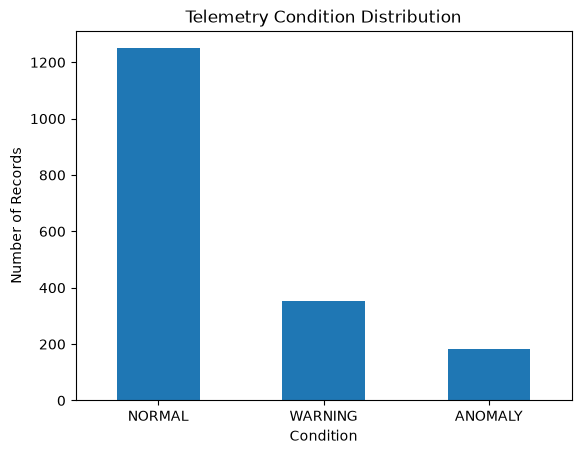

In [6]:
df["condition"].value_counts().plot(kind="bar")

plt.title("Telemetry Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

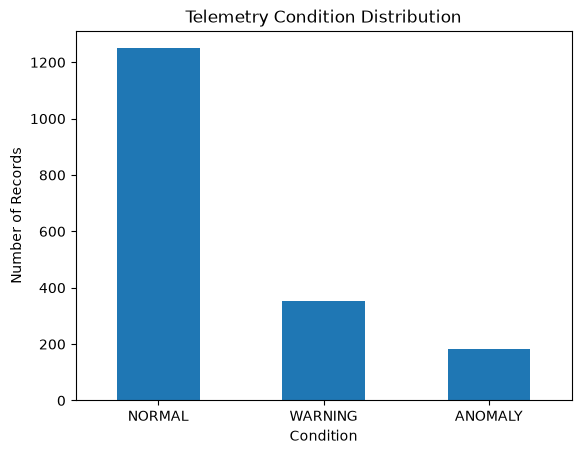

In [7]:
df["condition"].value_counts().plot(kind="bar")

plt.title("Telemetry Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

In [8]:
features = [
    "temperature",
    "humidity",
    "vibration",
    "hour",
    "day_of_week",
    "commodity",
    "container_id"
]

X = df[features]
y = df["condition"]

In [9]:
X.head()

,temperature,humidity,vibration,hour,day_of_week,commodity,container_id
0,3.94,71.79,0.29,17,3,Avocado,CONT_001
1,11.72,88.98,0.12,17,3,Mango,CONT_004
2,10.18,91.05,0.15,17,3,Tomato,CONT_005
3,6.54,85.30,0.17,17,3,Avocado,CONT_005
4,14.06,100.00,0.33,17,3,Tomato,CONT_005


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1428, 7)
Testing: (357, 7)


In [11]:
categorical_features = [
    "commodity",
    "container_id"
]

numerical_features = [
    "temperature",
    "humidity",
    "vibration",
    "hour",
    "day_of_week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [13]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "commodity",
    "container_id"
]

numerical_features = [
    "temperature",
    "humidity",
    "vibration",
    "hour",
    "day_of_week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

print("Random Forest model created.")

Random Forest model created.


In [17]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Pipeline created.")

Pipeline created.


In [18]:
print(X_train.shape)
print(y_train.shape)

(1428, 7)
(1428,)


In [19]:
features = [
    "temperature",
    "humidity",
    "vibration",
    "hour",
    "day_of_week",
    "commodity",
    "container_id"
]

X = df[features]
y = df["condition"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1428, 7)
Testing: (357, 7)


In [21]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [22]:
y_pred = pipeline.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 1.0


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     ANOMALY       1.00      1.00      1.00        37
      NORMAL       1.00      1.00      1.00       250
     WARNING       1.00      1.00      1.00        70

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357



In [25]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [26]:
y_pred = pipeline.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 1.0


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     ANOMALY       1.00      1.00      1.00        37
      NORMAL       1.00      1.00      1.00       250
     WARNING       1.00      1.00      1.00        70

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357



In [29]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['ANOMALY','NORMAL','WARNING']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['temperature','humidity','vibration',...,'day_of_week','commodity', 'container_id']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [30]:
y_pred = pipeline.predict(X_test)

print("Prediction completed.")
print(y_pred[:20])

Prediction completed.
['NORMAL' 'WARNING' 'WARNING' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL' 'NORMAL'
 'NORMAL' 'NORMAL' 'NORMAL' 'WARNING' 'NORMAL' 'NORMAL' 'WARNING' 'NORMAL'
 'NORMAL' 'WARNING' 'NORMAL' 'WARNING']


In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 1.0
Model Accuracy (%): 100.0 %


In [32]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

     ANOMALY       1.00      1.00      1.00        37
      NORMAL       1.00      1.00      1.00       250
     WARNING       1.00      1.00      1.00        70

    accuracy                           1.00       357
   macro avg       1.00      1.00      1.00       357
weighted avg       1.00      1.00      1.00       357



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 37   0   0]
 [  0 250   0]
 [  0   0  70]]


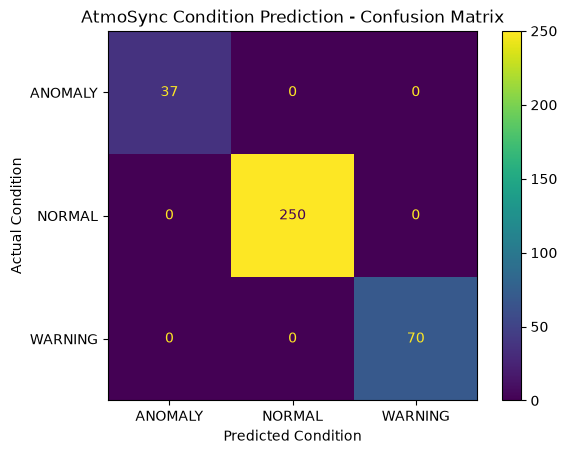

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

disp.plot()

plt.title("AtmoSync Condition Prediction - Confusion Matrix")
plt.xlabel("Predicted Condition")
plt.ylabel("Actual Condition")

plt.show()

In [35]:
print("Classes:")
print(pipeline.classes_)

Classes:
['ANOMALY' 'NORMAL' 'WARNING']


In [36]:
rf_model = pipeline.named_steps["model"]

print(rf_model)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)


In [37]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 14


In [38]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
11,numerical__vibration,0.564294
9,numerical__temperature,0.218099
10,numerical__humidity,0.174324
12,numerical__hour,0.009040
1,categorical__commodity_Banana,0.007102
0,categorical__commodity_Avocado,0.006569
3,categorical__commodity_Tomato,0.004044
2,categorical__commodity_Mango,0.003874
7,categorical__container_id_CONT_004,0.003030
4,categorical__container_id_CONT_001,0.002666


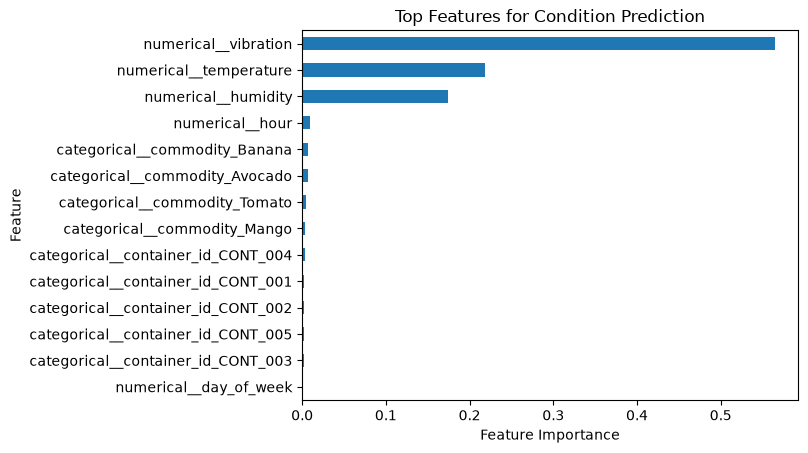

In [39]:
top_features = importance.head(15).sort_values(
    "importance"
)

top_features.plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top Features for Condition Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [40]:
prediction_probabilities = pipeline.predict_proba(X_test)

print(prediction_probabilities[:5])

[[0.    1.    0.   ]
 [0.055 0.01  0.935]
 [0.005 0.    0.995]
 [0.    1.    0.   ]
 [0.    1.    0.   ]]


In [41]:
confidence = prediction_probabilities.max(axis=1)

print("Average prediction confidence:")
print(round(confidence.mean(), 4))

Average prediction confidence:
0.9725


In [42]:
print("Minimum confidence:")
print(round(confidence.min(), 4))

print("Maximum confidence:")
print(round(confidence.max(), 4))

Minimum confidence:
0.535
Maximum confidence:
1.0


In [43]:
results = X_test.copy()

results["actual_condition"] = y_test.values
results["predicted_condition"] = y_pred
results["prediction_confidence"] = confidence

results.head(20)

,temperature,humidity,vibration,hour,day_of_week,commodity,container_id,actual_condition,predicted_condition,prediction_confidence
572,12.72,86.98,0.16,17,3,Mango,CONT_002,NORMAL,NORMAL,1.000
399,15.98,73.98,0.32,17,3,Avocado,CONT_002,WARNING,WARNING,0.935
1192,8.00,100.00,0.32,18,3,Mango,CONT_003,WARNING,WARNING,0.995
1511,11.38,88.98,0.10,18,3,Tomato,CONT_004,NORMAL,NORMAL,1.000
457,11.97,87.34,0.09,17,3,Avocado,CONT_004,NORMAL,NORMAL,1.000
1110,11.89,87.39,0.12,18,3,Tomato,CONT_002,NORMAL,NORMAL,1.000
505,11.13,85.34,0.11,17,3,Mango,CONT_005,NORMAL,NORMAL,1.000
994,13.46,93.01,0.12,18,3,Banana,CONT_005,NORMAL,NORMAL,1.000
384,10.69,85.46,0.14,17,3,Mango,CONT_001,NORMAL,NORMAL,1.000
1376,11.01,87.64,0.06,18,3,Tomato,CONT_005,NORMAL,NORMAL,1.000


In [44]:
results["prediction_correct"] = (
    results["actual_condition"]
    == results["predicted_condition"]
)

results["prediction_correct"].value_counts()

prediction_correct
True    357
Name: count, dtype: int64

In [45]:
correct = results["prediction_correct"].sum()
total = len(results)

print("Correct predictions:", correct)
print("Total predictions:", total)

print(
    "Prediction correctness:",
    round((correct / total) * 100, 2),
    "%"
)

Correct predictions: 357
Total predictions: 357
Prediction correctness: 100.0 %


In [46]:
incorrect_predictions = results[
    results["prediction_correct"] == False
]

print(
    "Incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions.head(20)

Incorrect predictions: 0


,temperature,humidity,vibration,hour,day_of_week,commodity,container_id,actual_condition,predicted_condition,prediction_confidence,prediction_correct


In [47]:
incorrect_predictions[
    [
        "temperature",
        "humidity",
        "vibration",
        "commodity",
        "container_id",
        "actual_condition",
        "predicted_condition",
        "prediction_confidence"
    ]
]

,temperature,humidity,vibration,commodity,container_id,actual_condition,predicted_condition,prediction_confidence


In [48]:
anomaly_results = results[
    results["actual_condition"] == "ANOMALY"
]

print(
    "Actual ANOMALY records:",
    len(anomaly_results)
)

print(
    "Correctly predicted ANOMALY:",
    (
        anomaly_results["predicted_condition"]
        == "ANOMALY"
    ).sum()
)

Actual ANOMALY records: 37
Correctly predicted ANOMALY: 37


In [49]:
anomaly_recall = (
    (
        anomaly_results["predicted_condition"]
        == "ANOMALY"
    ).sum()
    / len(anomaly_results)
)

print(
    "ANOMALY Recall:",
    round(anomaly_recall, 4)
)

print(
    "ANOMALY Recall (%):",
    round(anomaly_recall * 100, 2),
    "%"
)

ANOMALY Recall: 1.0
ANOMALY Recall (%): 100.0 %


In [50]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [51]:
final_pipeline.fit(X, y)

print("Final model trained on complete dataset.")

Final model trained on complete dataset.


In [52]:
all_predictions = final_pipeline.predict(X)

all_probabilities = final_pipeline.predict_proba(X)

all_confidence = all_probabilities.max(axis=1)

In [53]:
ml_predictions = df.copy()

ml_predictions["predicted_condition"] = all_predictions

ml_predictions["prediction_confidence"] = all_confidence

ml_predictions["prediction_correct"] = (
    ml_predictions["condition"]
    == ml_predictions["predicted_condition"]
)

In [54]:
ml_predictions[
    [
        "condition",
        "predicted_condition",
        "prediction_confidence",
        "prediction_correct"
    ]
].head(20)

,condition,predicted_condition,prediction_confidence,prediction_correct
0,WARNING,WARNING,0.995,True
1,NORMAL,NORMAL,1.000,True
2,NORMAL,NORMAL,1.000,True
3,NORMAL,NORMAL,0.995,True
4,WARNING,WARNING,1.000,True
5,NORMAL,NORMAL,1.000,True
6,NORMAL,NORMAL,1.000,True
7,NORMAL,NORMAL,1.000,True
8,NORMAL,NORMAL,1.000,True
9,NORMAL,NORMAL,1.000,True


In [55]:
print(
    ml_predictions["predicted_condition"].value_counts()
)

predicted_condition
NORMAL     1249
WARNING     352
ANOMALY     184
Name: count, dtype: int64


In [56]:
comparison = pd.DataFrame({
    "Actual": ml_predictions["condition"].value_counts(),
    "Predicted": ml_predictions["predicted_condition"].value_counts()
})

comparison

,Actual,Predicted
NORMAL,1249,1249
WARNING,352,352
ANOMALY,184,184


In [57]:
output_path = "../data/processed/ml_predictions.csv"

ml_predictions.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../data/processed/ml_predictions.csv


In [58]:
output_path = "../data/processed/ml_predictions.csv"

ml_predictions.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../data/processed/ml_predictions.csv


In [59]:
import joblib

In [60]:
model_path = "../models/condition_prediction_model.pkl"

joblib.dump(
    final_pipeline,
    model_path
)

print("Model saved:", model_path)

Model saved: ../models/condition_prediction_model.pkl


In [61]:
import os

print(
    "Model exists:",
    os.path.exists("../models/condition_prediction_model.pkl")
)

print(
    "Predictions file exists:",
    os.path.exists("../data/processed/ml_predictions.csv")
)

Model exists: True
Predictions file exists: True


In [62]:
loaded_model = joblib.load(
    "../models/condition_prediction_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [63]:
test_prediction = loaded_model.predict(
    X_test.head(5)
)

print(test_prediction)

['NORMAL' 'WARNING' 'WARNING' 'NORMAL' 'NORMAL']


In [64]:
print("========== ATmosync ML SUMMARY ==========")

print("Total telemetry records:", len(df))

print(
    "Training records:",
    len(X_train)
)

print(
    "Testing records:",
    len(X_test)
)

print(
    "Model accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ANOMALY recall:",
    round(anomaly_recall * 100, 2),
    "%"
)

print(
    "Average prediction confidence:",
    round(confidence.mean() * 100, 2),
    "%"
)

========== ATmosync ML SUMMARY ==========
Total telemetry records: 1785
Training records: 1428
Testing records: 357
Model accuracy: 100.0 %
ANOMALY recall: 100.0 %
Average prediction confidence: 97.25 %


In [66]:
## Business Interpretation

#The machine learning layer predicts telemetry conditions as
#NORMAL, WARNING, or ANOMALY using temperature, humidity,
#vibration, time, commodity, and container information.

#The model provides an additional predictive signal for the
#AtmoSync decision-support pipeline.

#Prediction results can be used to identify telemetry records
#that may require additional monitoring or investigation.

#The model should not be interpreted as a direct prediction of
#actual commodity spoilage because the current dataset is
#simulated and the condition labels are generated by simulation
#logic rather than independently observed spoilage outcomes.

In [67]:
## Machine Learning Pipeline

#1. Load processed telemetry data
#2. Select sensor and contextual features
#3. Define condition as the target variable
#4. Encode categorical variables
#5. Split data into training and testing sets
#6. Train Random Forest classifier
#7. Evaluate model using accuracy, precision, recall and F1-score
#8. Analyze confusion matrix
#9. Analyze feature importance
#10. Generate prediction probabilities
#11. Train final model on complete dataset
#12. Save predictions
#13. Serialize the trained model